# 🎓 Student Performance - Machine Learning Project

Ce projet consiste à analyser les performances des étudiants en utilisant différentes techniques de machine learning : régression, classification et clustering.

## 1. Chargement et exploration du dataset :
Dans cette partie, nous chargeons le dataset et analysons sa structure, ses colonnes et ses statistiques.

In [2]:
import pandas as pd

# charger le dataset
df = pd.read_csv("StudentsPerformance.csv")

# afficher les 5 premières lignes
print(df.head())

# infos générales
print(df.info())

# statistiques
print(df.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

## 2. Visualisation des données :
Dans cette partie, nous utilisons des graphiques pour analyser la distribution des notes et la corrélation entre les variables.

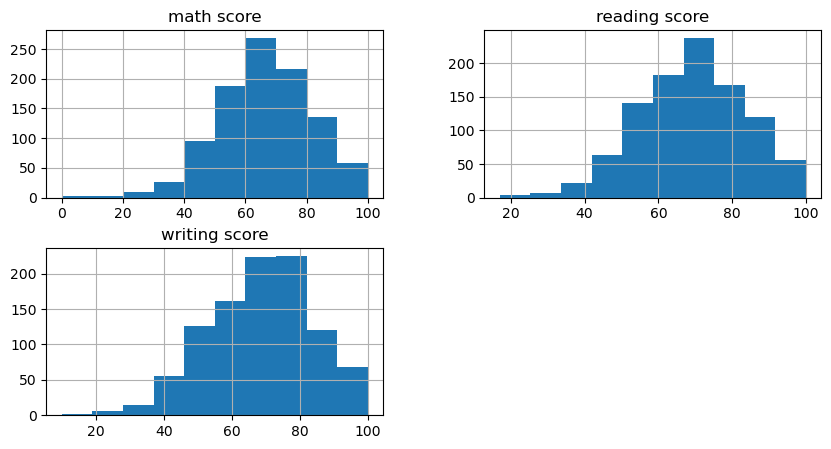

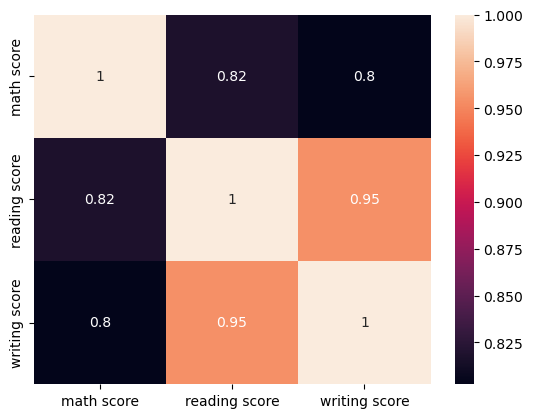

In [38]:
df[['math score', 'reading score', 'writing score']].hist(figsize=(10,5))
plt.show()

sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.show()

## 3. Prétraitement des données : Encodage des variables catégorielles

In [4]:
# transformer les variables catégorielles en nombres
df_encoded = pd.get_dummies(df, drop_first=True)

# afficher
print(df_encoded.head())

   math score  reading score  writing score  gender_male  \
0          72             72             74        False   
1          69             90             88        False   
2          90             95             93        False   
3          47             57             44         True   
4          76             78             75         True   

   race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                    True                   False                   False   
1                   False                    True                   False   
2                    True                   False                   False   
3                   False                   False                   False   
4                   False                    True                   False   

   race/ethnicity_group E  parental level of education_bachelor's degree  \
0                   False                                           True   
1                   Fals

# 4. RÉGRESSION :

#### Définir X et y :

In [5]:
# variables explicatives
X = df_encoded.drop("math score", axis=1)

# variable cible
y = df_encoded["math score"]

#### Split :

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Les Modèles:

### Modèle 1 : Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

### Modèle 2 : Decision Tree Regressor

In [24]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

### Modèle 3 : KNN Regressor

In [25]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

## Évaluation des Modèles :

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

print("LR R2:", r2_score(y_test, y_pred_lr))
print("DT R2:", r2_score(y_test, y_pred_dt))
print("KNN R2:", r2_score(y_test, y_pred_knn))

LR R2: 0.8804332983749564
DT R2: 0.7309713551169894
KNN R2: 0.6959764673393102


### Analyse : 
Le modèle Linear Regression donne le meilleur score R2 (~0.88),ce qui signifie qu’il est le plus performant pour ce dataset.

In [36]:
print("LR MSE:", mean_squared_error(y_test, y_pred_lr))
print("DT MSE:", mean_squared_error(y_test, y_pred_dt))
print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))

LR MSE: 4296.533576979647
DT MSE: 4354.895
KNN MSE: 4234.8606


### Analyse :

Le MSE indique que le modèle KNN est légèrement le plus précis.
Cependant, le score R2 montre que Linear Regression explique mieux la variance des données.

Ainsi, même si KNN a une erreur légèrement plus faible, Linear Regression reste le modèle
le plus fiable globalement.

Conclusion : Linear Regression est le meilleur compromis pour ce problème.

# 5. CLASSIFICATION :

### Créer la cible :

In [28]:
df['result'] = df['math score'] >= 50

### définir X et y :

In [37]:
X = df_encoded.drop("math score", axis=1)
y = df['result']

### Split :

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Les Modèles :

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

clf_dt = DecisionTreeClassifier(max_depth=5)
clf_knn = KNeighborsClassifier()

clf_dt.fit(X_train, y_train)
clf_knn.fit(X_train, y_train)

## Évaluation :

In [40]:
from sklearn.metrics import accuracy_score

print("DT:", accuracy_score(y_test, clf_dt.predict(X_test)))
print("KNN:", accuracy_score(y_test, clf_knn.predict(X_test)))

DT: 1.0
KNN: 0.97


### Analyse :
Le Decision Tree donne une précision de 100%, ce qui peut indiquer un sur apprentissage.

Le KNN donne une précision de 97%, ce qui reste très bon et plus fiable.

# 6. Matrice de confusion :

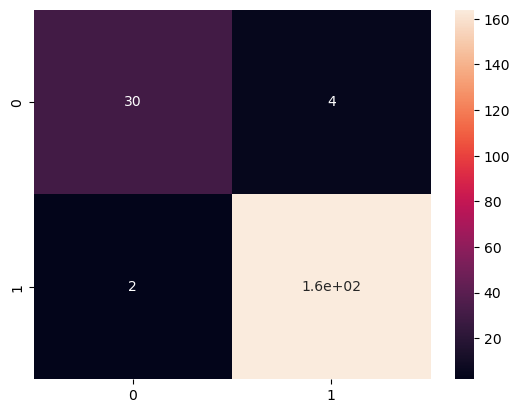

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, clf_knn.predict(X_test))
sns.heatmap(cm, annot=True)
plt.show()

# 7. CLUSTERING :

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# prendre seulement les scores
X_cluster = df[['math score', 'reading score', 'writing score']]

# normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# appliquer K-means (3 groupes)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# afficher
print(df[['math score','reading score','writing score','cluster']].head())

   math score  reading score  writing score  cluster
0          72             72             74        0
1          69             90             88        2
2          90             95             93        2
3          47             57             44        1
4          76             78             75        2


##  Visualisation des clusters :

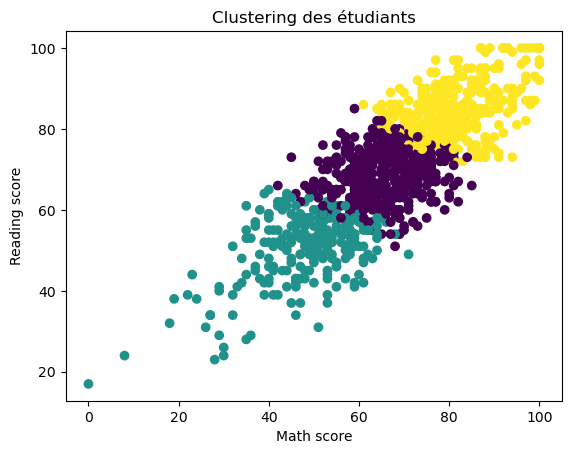

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df['math score'], df['reading score'], c=df['cluster'])
plt.xlabel("Math score")
plt.ylabel("Reading score")
plt.title("Clustering des étudiants")
plt.show()

### Analyse :
Le clustering permet de regrouper les étudiants en 3 catégories :faible, moyen et bon niveau.

# Conclusion :

Dans ce projet, nous avons analysé les performances des étudiants
en utilisant plusieurs techniques de machine learning.

La régression a montré que Linear Regression est le modèle le plus performant.
La classification permet de prédire la réussite des étudiants.
Le clustering a permis de segmenter les étudiants en différents groupes.

Ce projet nous a permis de comprendre les étapes essentielles :
prétraitement, modélisation et évaluation.